<a href="https://colab.research.google.com/github/Charithasri20/titanic-data-analysis-project/blob/main/day10_titanic_data_analysis_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Day 10 — Titanic Data Analysis Project
## April 12, 2026 — B.Tech AIML 30 Day Challenge

### Complete Pipeline
Load → Clean → EDA → Visualize →
Feature Engineer → Train 3 Models → Evaluate → Save

### Author
B.Tech AIML Graduate — Hyderabad

In [1]:
# Day 10 — Complete Titanic Data Analysis Project
# April 12, 2026

# Data
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# ML
from sklearn.model_selection import (
    train_test_split, cross_val_score
)
from sklearn.preprocessing import (
    LabelEncoder, StandardScaler
)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)
import pickle
import warnings
warnings.filterwarnings("ignore")

print("✅ All libraries imported successfully!")
print(f"   Pandas  : {pd.__version__}")
print(f"   NumPy   : {np.__version__}")
print(f"   Seaborn : {sns.__version__}")

✅ All libraries imported successfully!
   Pandas  : 2.2.2
   NumPy   : 2.0.2
   Seaborn : 0.13.2


## Step 1 — Load and Understand the Data

In [2]:
# Load Titanic dataset
url = ("https://raw.githubusercontent.com/"
       "datasciencedojo/datasets/master/titanic.csv")

df = pd.read_csv(url)
print("✅ Dataset loaded!")
print(f"\n{'='*50}")
print("DATASET OVERVIEW")
print(f"{'='*50}")
print(f"Rows    : {df.shape[0]}")
print(f"Columns : {df.shape[1]}")
print(f"\nColumn names:")
for col in df.columns:
    print(f"  {col}")

✅ Dataset loaded!

DATASET OVERVIEW
Rows    : 891
Columns : 12

Column names:
  PassengerId
  Survived
  Pclass
  Name
  Sex
  Age
  SibSp
  Parch
  Ticket
  Fare
  Cabin
  Embarked


In [3]:
print("FIRST 5 ROWS:")
print(df.head())

print("\nLAST 5 ROWS:")
print(df.tail())

print("\nCOLUMN DATA TYPES + NULL COUNT:")
print(df.info())

print("\nSTATISTICAL SUMMARY:")
print(df.describe().round(2))

FIRST 5 ROWS:
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN

In [4]:
print("MISSING VALUE ANALYSIS:")
print("=" * 45)

missing_count = df.isnull().sum()
missing_pct   = (df.isnull().sum() /
                 len(df) * 100).round(2)

missing_df = pd.DataFrame({
    "Missing Count"  : missing_count,
    "Missing Percent": missing_pct
}).sort_values("Missing Percent", ascending=False)

print(missing_df[missing_df["Missing Count"] > 0])

print("\nDecision for each:")
print("  Age      → Fill with median (skewed data)")
print("  Cabin    → Drop (77% missing)")
print("  Embarked → Fill with mode (2 missing only)")

MISSING VALUE ANALYSIS:
          Missing Count  Missing Percent
Cabin               687            77.10
Age                 177            19.87
Embarked              2             0.22

Decision for each:
  Age      → Fill with median (skewed data)
  Cabin    → Drop (77% missing)
  Embarked → Fill with mode (2 missing only)


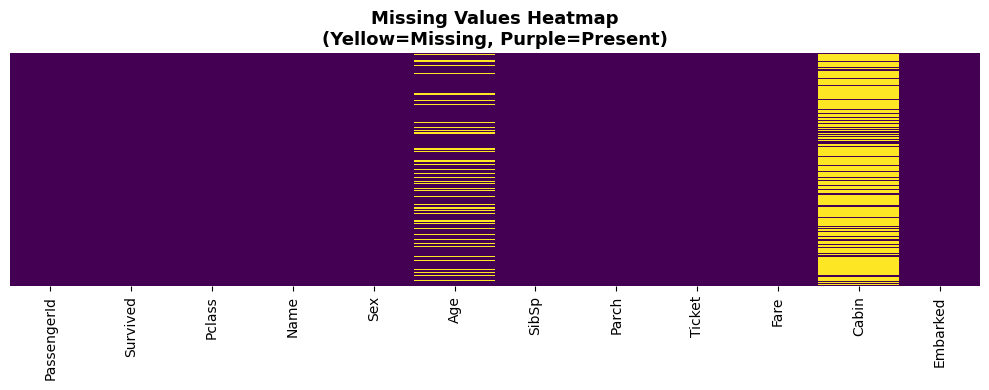

Chart saved: 01_missing_heatmap.png


In [5]:
plt.figure(figsize=(10, 4))
sns.heatmap(df.isnull(),
            yticklabels=False,
            cbar=False,
            cmap="viridis")
plt.title("Missing Values Heatmap\n"
          "(Yellow=Missing, Purple=Present)",
          fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("01_missing_heatmap.png", dpi=150)
plt.show()
print("Chart saved: 01_missing_heatmap.png")

## Step 2 — Data Cleaning

In [6]:
# Work on a copy — never modify original
df_clean = df.copy()

print("CLEANING STEPS:")
print("=" * 45)

# 1. Fill Age with median
age_median = df_clean["Age"].median()
df_clean["Age"].fillna(age_median, inplace=True)
print(f"✅ Age: filled {df['Age'].isnull().sum()} "
      f"nulls with median ({age_median})")

# 2. Fill Embarked with mode
emb_mode = df_clean["Embarked"].mode()[0]
df_clean["Embarked"].fillna(emb_mode, inplace=True)
print(f"✅ Embarked: filled 2 nulls with "
      f"mode ({emb_mode})")

# 3. Drop Cabin
df_clean.drop("Cabin", axis=1, inplace=True)
print("✅ Cabin: dropped (77% missing)")

# 4. Drop unnecessary columns
df_clean.drop(["Name","Ticket","PassengerId"],
              axis=1, inplace=True)
print("✅ Name, Ticket, PassengerId: dropped")

print(f"\nShape after cleaning: {df_clean.shape}")
print(f"Any nulls remaining: "
      f"{df_clean.isnull().sum().sum()}")
print("\nCleaned data:")
print(df_clean.head())

CLEANING STEPS:
✅ Age: filled 177 nulls with median (28.0)
✅ Embarked: filled 2 nulls with mode (S)
✅ Cabin: dropped (77% missing)
✅ Name, Ticket, PassengerId: dropped

Shape after cleaning: (891, 8)
Any nulls remaining: 0

Cleaned data:
   Survived  Pclass     Sex   Age  SibSp  Parch     Fare Embarked
0         0       3    male  22.0      1      0   7.2500        S
1         1       1  female  38.0      1      0  71.2833        C
2         1       3  female  26.0      0      0   7.9250        S
3         1       1  female  35.0      1      0  53.1000        S
4         0       3    male  35.0      0      0   8.0500        S


## Step 3 — Exploratory Data Analysis (EDA)

In [7]:
print("EDA — SURVIVAL ANALYSIS")
print("=" * 50)

# Overall survival
total      = len(df_clean)
survived   = df_clean["Survived"].sum()
not_surv   = total - survived
surv_rate  = df_clean["Survived"].mean()

print(f"Total passengers   : {total}")
print(f"Survived           : {survived} "
      f"({surv_rate:.1%})")
print(f"Did not survive    : {not_surv} "
      f"({1-surv_rate:.1%})")

EDA — SURVIVAL ANALYSIS
Total passengers   : 891
Survived           : 342 (38.4%)
Did not survive    : 549 (61.6%)


In [8]:
print("EDA BY FEATURES:")
print("=" * 50)

# By Gender
print("\n1. BY GENDER:")
gender = df_clean.groupby("Sex")["Survived"].agg(
    Survived="sum",
    Total="count",
    Rate="mean"
).round(3)
print(gender)
print("→ Females survived 74% vs Males 19%")

# By Class
print("\n2. BY PASSENGER CLASS:")
pclass = df_clean.groupby("Pclass")["Survived"].agg(
    Survived="sum",
    Total="count",
    Rate="mean"
).round(3)
print(pclass)
print("→ 1st class 63%, 2nd 47%, 3rd 24%")

# By Embarked
print("\n3. BY EMBARKATION PORT:")
emb = df_clean.groupby("Embarked")["Survived"].agg(
    Survived="sum",
    Total="count",
    Rate="mean"
).round(3)
print(emb)

# Age stats
print("\n4. AGE ANALYSIS:")
print(f"Avg age survived     : "
      f"{df_clean[df_clean['Survived']==1]['Age'].mean():.1f}")
print(f"Avg age not survived : "
      f"{df_clean[df_clean['Survived']==0]['Age'].mean():.1f}")

EDA BY FEATURES:

1. BY GENDER:
        Survived  Total   Rate
Sex                           
female       233    314  0.742
male         109    577  0.189
→ Females survived 74% vs Males 19%

2. BY PASSENGER CLASS:
        Survived  Total   Rate
Pclass                        
1            136    216  0.630
2             87    184  0.473
3            119    491  0.242
→ 1st class 63%, 2nd 47%, 3rd 24%

3. BY EMBARKATION PORT:
          Survived  Total   Rate
Embarked                        
C               93    168  0.554
Q               30     77  0.390
S              219    646  0.339

4. AGE ANALYSIS:
Avg age survived     : 28.3
Avg age not survived : 30.0


## Step 4 — Visualizations (3 Charts)

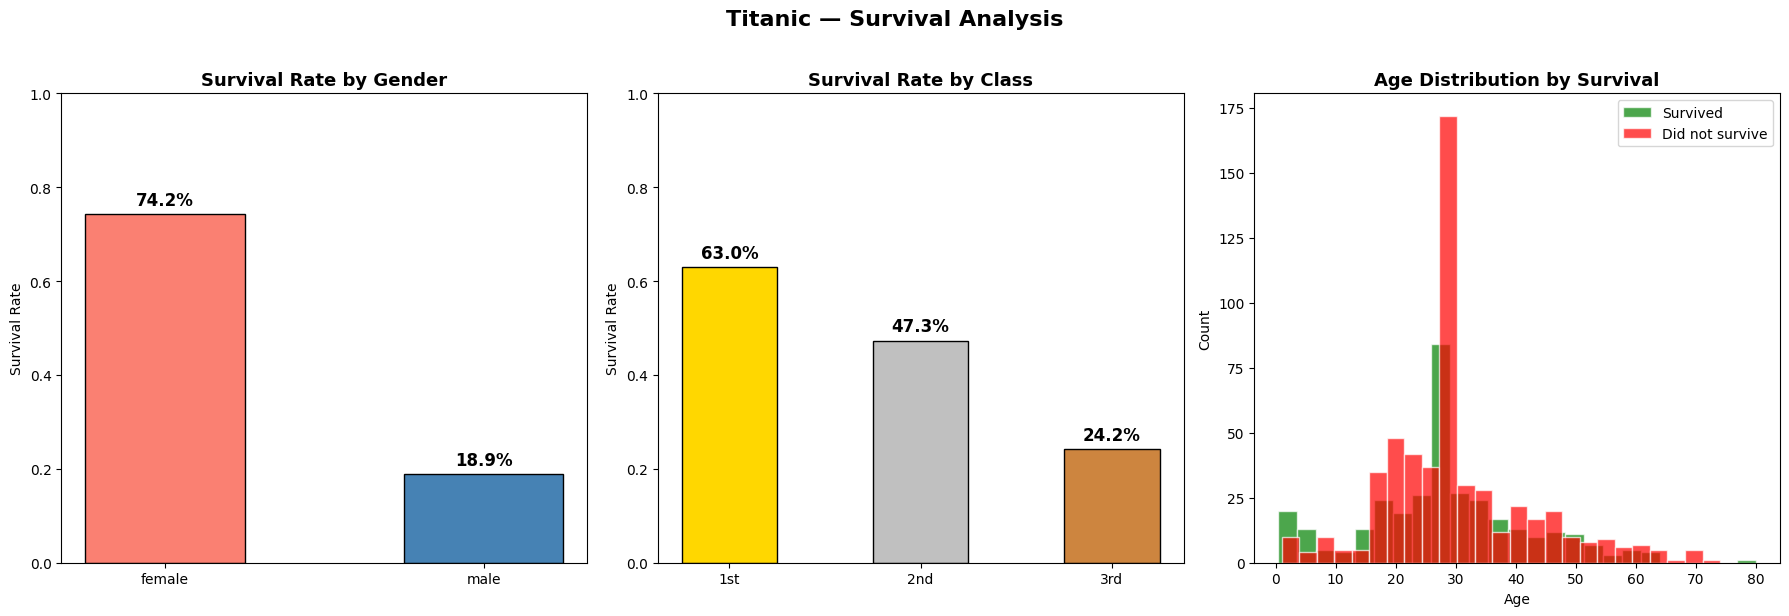

Chart saved: 02_survival_analysis.png


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("Titanic — Survival Analysis",
             fontsize=16, fontweight="bold",
             y=1.02)

# Chart 1A — Survival by Gender
gender_data = df_clean.groupby(
    "Sex")["Survived"].mean()
axes[0].bar(gender_data.index,
            gender_data.values,
            color=["salmon","steelblue"],
            edgecolor="black", width=0.5)
axes[0].set_title("Survival Rate by Gender",
                  fontsize=13, fontweight="bold")
axes[0].set_ylabel("Survival Rate")
axes[0].set_ylim(0, 1)
for i, v in enumerate(gender_data.values):
    axes[0].text(i, v+0.02, f"{v:.1%}",
                 ha="center", fontweight="bold",
                 fontsize=12)

# Chart 1B — Survival by Class
class_data = df_clean.groupby(
    "Pclass")["Survived"].mean()
axes[1].bar(["1st","2nd","3rd"],
            class_data.values,
            color=["gold","silver","peru"],
            edgecolor="black", width=0.5)
axes[1].set_title("Survival Rate by Class",
                  fontsize=13, fontweight="bold")
axes[1].set_ylabel("Survival Rate")
axes[1].set_ylim(0, 1)
for i, v in enumerate(class_data.values):
    axes[1].text(i, v+0.02, f"{v:.1%}",
                 ha="center", fontweight="bold",
                 fontsize=12)

# Chart 1C — Age Distribution
axes[2].hist(
    df_clean[df_clean["Survived"]==1]["Age"],
    bins=25, alpha=0.7, color="green",
    label="Survived", edgecolor="white")
axes[2].hist(
    df_clean[df_clean["Survived"]==0]["Age"],
    bins=25, alpha=0.7, color="red",
    label="Did not survive", edgecolor="white")
axes[2].set_title("Age Distribution by Survival",
                  fontsize=13, fontweight="bold")
axes[2].set_xlabel("Age")
axes[2].set_ylabel("Count")
axes[2].legend()

plt.tight_layout()
plt.savefig("02_survival_analysis.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("Chart saved: 02_survival_analysis.png")

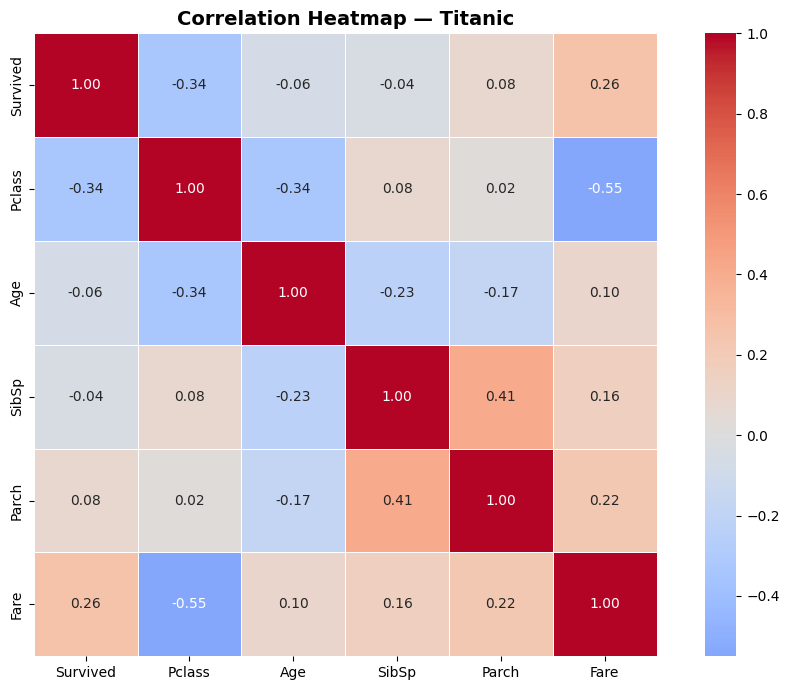

Chart saved: 03_correlation_heatmap.png

How to read:
  1.0 = perfect positive correlation
 -1.0 = perfect negative correlation
  0   = no correlation

Key findings:
  Fare     → positive with Survived
  Pclass   → negative with Survived
  Sex(enc) → strong predictor


In [10]:
plt.figure(figsize=(10, 7))

# Get numeric columns only
num_cols = df_clean.select_dtypes(
    include=[np.number]).columns
corr = df_clean[num_cols].corr().round(2)

sns.heatmap(corr,
            annot=True,
            fmt=".2f",
            cmap="coolwarm",
            center=0,
            square=True,
            linewidths=0.5,
            annot_kws={"size":10})

plt.title("Correlation Heatmap — Titanic",
          fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("03_correlation_heatmap.png",
            dpi=150, bbox_inches="tight")
plt.show()

print("Chart saved: 03_correlation_heatmap.png")
print("\nHow to read:")
print("  1.0 = perfect positive correlation")
print(" -1.0 = perfect negative correlation")
print("  0   = no correlation")
print("\nKey findings:")
print("  Fare     → positive with Survived")
print("  Pclass   → negative with Survived")
print("  Sex(enc) → strong predictor")

<Figure size 1200x500 with 0 Axes>

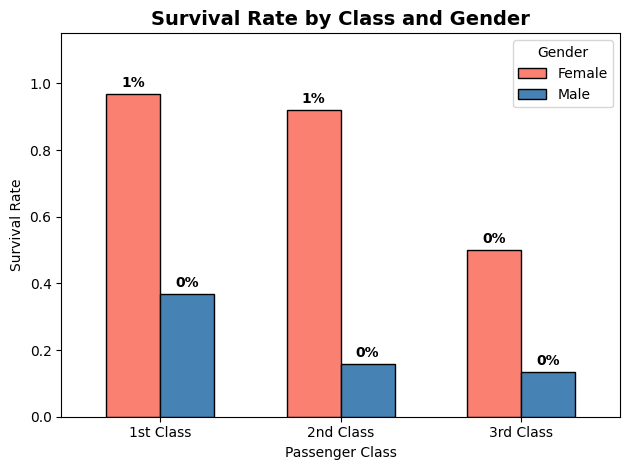

Chart saved: 04_class_gender_survival.png


In [11]:
plt.figure(figsize=(12, 5))

pivot = df_clean.pivot_table(
    values  = "Survived",
    index   = "Pclass",
    columns = "Sex",
    aggfunc = "mean"
).round(3)

pivot.plot(kind="bar",
           color=["salmon","steelblue"],
           edgecolor="black",
           width=0.6)

plt.title("Survival Rate by Class and Gender",
          fontsize=14, fontweight="bold")
plt.xlabel("Passenger Class")
plt.ylabel("Survival Rate")
plt.xticks([0,1,2],
           ["1st Class","2nd Class","3rd Class"],
           rotation=0)
plt.legend(["Female","Male"], title="Gender")
plt.ylim(0, 1.15)

for container in plt.gca().containers:
    plt.gca().bar_label(container,
                        fmt="%.0f%%",
                        padding=3,
                        fontweight="bold")

plt.tight_layout()
plt.savefig("04_class_gender_survival.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("Chart saved: 04_class_gender_survival.png")

## Step 5 — Feature Engineering

In [12]:
df_model = df_clean.copy()

print("FEATURE ENGINEERING:")
print("=" * 45)

# 1. Encode Sex
le = LabelEncoder()
df_model["Sex"] = le.fit_transform(df_model["Sex"])
print("✅ Sex encoded: female=0, male=1")

# 2. Encode Embarked
df_model["Embarked"] = le.fit_transform(
    df_model["Embarked"]
)
print("✅ Embarked encoded: C=0, Q=1, S=2")

# 3. Create FamilySize
df_model["FamilySize"] = (df_model["SibSp"] +
                          df_model["Parch"] + 1)
print("✅ FamilySize created: SibSp+Parch+1")

# 4. Create IsAlone
df_model["IsAlone"] = (
    df_model["FamilySize"] == 1
).astype(int)
print("✅ IsAlone created: 1=alone, 0=with family")

# 5. Create AgeGroup
df_model["AgeGroup"] = pd.cut(
    df_model["Age"],
    bins  = [0, 12, 18, 35, 60, 100],
    labels= [0, 1, 2, 3, 4]
).astype(int)
print("✅ AgeGroup created: 0=child to 4=senior")

print(f"\nFinal dataset shape: {df_model.shape}")
print(f"Columns: {df_model.columns.tolist()}")
print(df_model.head())

FEATURE ENGINEERING:
✅ Sex encoded: female=0, male=1
✅ Embarked encoded: C=0, Q=1, S=2
✅ FamilySize created: SibSp+Parch+1
✅ IsAlone created: 1=alone, 0=with family
✅ AgeGroup created: 0=child to 4=senior

Final dataset shape: (891, 11)
Columns: ['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked', 'FamilySize', 'IsAlone', 'AgeGroup']
   Survived  Pclass  Sex   Age  SibSp  Parch     Fare  Embarked  FamilySize  \
0         0       3    1  22.0      1      0   7.2500         2           2   
1         1       1    0  38.0      1      0  71.2833         0           2   
2         1       3    0  26.0      0      0   7.9250         2           1   
3         1       1    0  35.0      1      0  53.1000         2           2   
4         0       3    1  35.0      0      0   8.0500         2           1   

   IsAlone  AgeGroup  
0        0         2  
1        0         3  
2        1         2  
3        0         2  
4        1         2  


## Step 6 — Train/Test Split

In [13]:
features = ["Pclass","Sex","Age","SibSp",
            "Parch","Fare","FamilySize",
            "IsAlone","AgeGroup"]

X = df_model[features]
y = df_model["Survived"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size   = 0.2,
    random_state= 42,
    stratify    = y
)

print("TRAIN/TEST SPLIT:")
print("=" * 45)
print(f"Total samples    : {len(X)}")
print(f"Training samples : {len(X_train)} (80%)")
print(f"Testing samples  : {len(X_test)}  (20%)")
print(f"\nClass balance in train:")
print(f"  Survived    : {y_train.sum()} "
      f"({y_train.mean():.1%})")
print(f"  Not survived: {(y_train==0).sum()} "
      f"({(y_train==0).mean():.1%})")

TRAIN/TEST SPLIT:
Total samples    : 891
Training samples : 712 (80%)
Testing samples  : 179  (20%)

Class balance in train:
  Survived    : 273 (38.3%)
  Not survived: 439 (61.7%)


## Step 7 — Train 3 ML Models

In [14]:
# Scale for Logistic Regression
scaler         = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("TRAINING 3 MODELS:")
print("=" * 45)

# Model 1: Logistic Regression
lr = LogisticRegression(
    max_iter=1000, random_state=42
)
lr.fit(X_train_scaled, y_train)
lr_pred = lr.predict(X_test_scaled)
lr_acc  = accuracy_score(y_test, lr_pred)
print(f"1. Logistic Regression : {lr_acc:.4f} "
      f"({lr_acc:.1%})")

# Model 2: Decision Tree
dt = DecisionTreeClassifier(
    max_depth=5, random_state=42
)
dt.fit(X_train, y_train)
dt_pred = dt.predict(X_test)
dt_acc  = accuracy_score(y_test, dt_pred)
print(f"2. Decision Tree       : {dt_acc:.4f} "
      f"({dt_acc:.1%})")

# Model 3: Random Forest
rf = RandomForestClassifier(
    n_estimators=100, max_depth=5,
    random_state=42, n_jobs=-1
)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
rf_acc  = accuracy_score(y_test, rf_pred)
print(f"3. Random Forest       : {rf_acc:.4f} "
      f"({rf_acc:.1%})")

best = max(lr_acc, dt_acc, rf_acc)
print(f"\nBest accuracy: {best:.1%}")

TRAINING 3 MODELS:
1. Logistic Regression : 0.8156 (81.6%)
2. Decision Tree       : 0.7598 (76.0%)
3. Random Forest       : 0.8045 (80.4%)

Best accuracy: 81.6%


## Step 8 — Model Evaluation

In [15]:
print("DETAILED EVALUATION — RANDOM FOREST")
print("=" * 50)

print(f"Accuracy : {rf_acc:.4f} ({rf_acc:.1%})")
print(f"\nClassification Report:")
print(classification_report(
    y_test, rf_pred,
    target_names=["Not Survived","Survived"]
))

cm = confusion_matrix(y_test, rf_pred)
print("Confusion Matrix:")
print(f"  TN={cm[0][0]}  FP={cm[0][1]}")
print(f"  FN={cm[1][0]}  TP={cm[1][1]}")
print(f"\n  Correct  : {cm[0][0]+cm[1][1]}")
print(f"  Incorrect: {cm[0][1]+cm[1][0]}")

DETAILED EVALUATION — RANDOM FOREST
Accuracy : 0.8045 (80.4%)

Classification Report:
              precision    recall  f1-score   support

Not Survived       0.79      0.93      0.85       110
    Survived       0.84      0.61      0.71        69

    accuracy                           0.80       179
   macro avg       0.82      0.77      0.78       179
weighted avg       0.81      0.80      0.80       179

Confusion Matrix:
  TN=102  FP=8
  FN=27  TP=42

  Correct  : 144
  Incorrect: 35


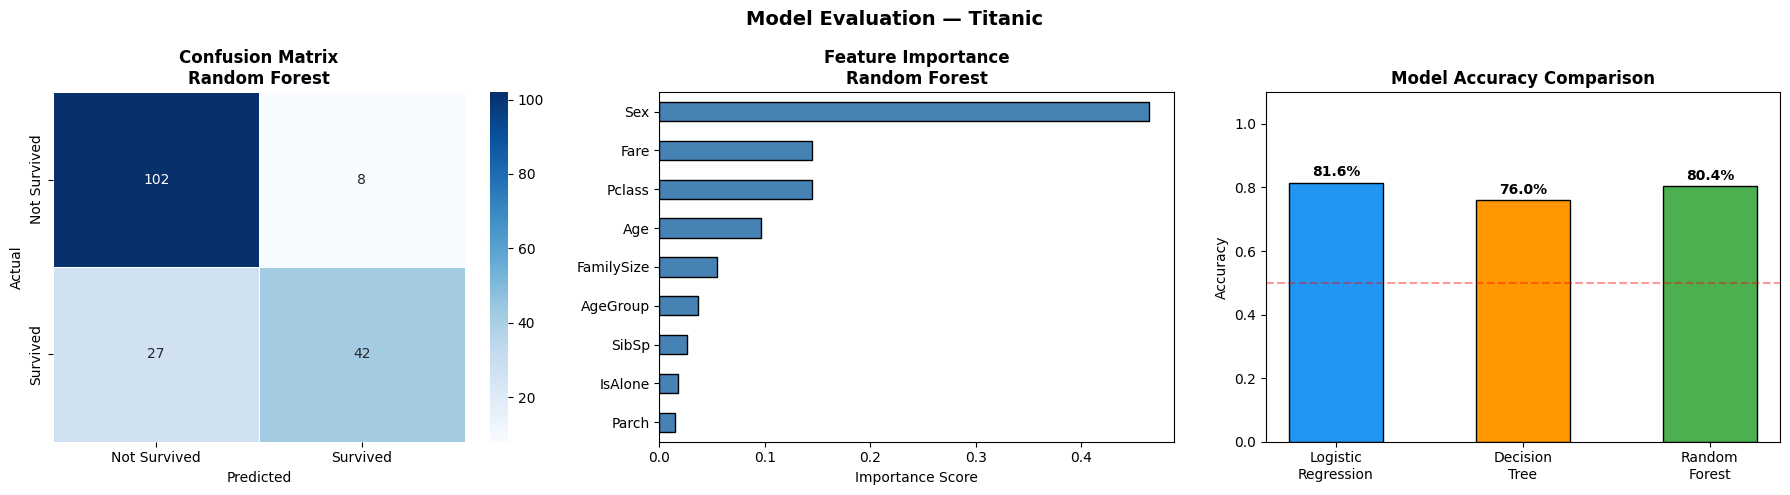

Chart saved: 05_model_evaluation.png


In [16]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Model Evaluation — Titanic",
             fontsize=14, fontweight="bold")

# Chart 1 — Confusion Matrix
sns.heatmap(cm, annot=True, fmt="d",
            cmap="Blues", ax=axes[0],
            xticklabels=["Not Survived","Survived"],
            yticklabels=["Not Survived","Survived"],
            linewidths=0.5)
axes[0].set_title("Confusion Matrix\n"
                  "Random Forest",
                  fontsize=12, fontweight="bold")
axes[0].set_ylabel("Actual")
axes[0].set_xlabel("Predicted")

# Chart 2 — Feature Importance
feat_imp = pd.Series(
    rf.feature_importances_,
    index=features
).sort_values()
feat_imp.plot(kind="barh",
              ax=axes[1],
              color="steelblue",
              edgecolor="black")
axes[1].set_title("Feature Importance\n"
                  "Random Forest",
                  fontsize=12, fontweight="bold")
axes[1].set_xlabel("Importance Score")

# Chart 3 — Model Comparison
models = ["Logistic\nRegression",
          "Decision\nTree",
          "Random\nForest"]
accs   = [lr_acc, dt_acc, rf_acc]
colors = ["#2196F3","#FF9800","#4CAF50"]
bars   = axes[2].bar(models, accs,
                     color=colors,
                     edgecolor="black",
                     width=0.5)
axes[2].set_title("Model Accuracy Comparison",
                  fontsize=12, fontweight="bold")
axes[2].set_ylabel("Accuracy")
axes[2].set_ylim(0, 1.1)
axes[2].axhline(y=0.5, color="red",
                linestyle="--", alpha=0.4)
for bar, acc in zip(bars, accs):
    axes[2].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.02,
        f"{acc:.1%}",
        ha="center", fontweight="bold"
    )

plt.tight_layout()
plt.savefig("05_model_evaluation.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("Chart saved: 05_model_evaluation.png")

## Step 9 — Save Model

In [17]:
# Save best model (Random Forest)
with open("titanic_rf_model.pkl", "wb") as f:
    pickle.dump(rf, f)
print("✅ RF model saved: titanic_rf_model.pkl")

with open("titanic_scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)
print("✅ Scaler saved: titanic_scaler.pkl")

# Verify
with open("titanic_rf_model.pkl", "rb") as f:
    loaded = pickle.load(f)
v_acc = accuracy_score(y_test,
                        loaded.predict(X_test))
print(f"\n✅ Loaded model accuracy: {v_acc:.4f}")
print("Save and load verified!")

✅ RF model saved: titanic_rf_model.pkl
✅ Scaler saved: titanic_scaler.pkl

✅ Loaded model accuracy: 0.8045
Save and load verified!


## Step 10 — Predict New Passengers

In [18]:
new_pass = pd.DataFrame({
    "Pclass"    : [1,   3,   2,   3,   1  ],
    "Sex"       : [0,   1,   0,   1,   1  ],
    "Age"       : [25,  30,  35,  20,  50 ],
    "SibSp"     : [1,   0,   0,   1,   0  ],
    "Parch"     : [0,   0,   1,   0,   0  ],
    "Fare"      : [80,  8,   20,  10,  100],
    "FamilySize": [2,   1,   2,   2,   1  ],
    "IsAlone"   : [0,   1,   0,   0,   1  ],
    "AgeGroup"  : [2,   2,   2,   2,   3  ],
})

descriptions = [
    "Female, 1st class, with husband",
    "Male,   3rd class, alone",
    "Female, 2nd class, with child",
    "Male,   3rd class, with sibling",
    "Male,   1st class, alone"
]

preds = loaded.predict(new_pass)
probs = loaded.predict_proba(new_pass)

print("PREDICTIONS FOR NEW PASSENGERS:")
print("=" * 60)
for desc, pred, prob in zip(
    descriptions, preds, probs
):
    result = "✅ SURVIVED" if pred==1 \
             else "❌ DID NOT SURVIVE"
    print(f"\n  {desc}")
    print(f"  → {result}")
    print(f"  → Survival probability: {prob[1]:.1%}")

PREDICTIONS FOR NEW PASSENGERS:

  Female, 1st class, with husband
  → ✅ SURVIVED
  → Survival probability: 93.5%

  Male,   3rd class, alone
  → ❌ DID NOT SURVIVE
  → Survival probability: 12.9%

  Female, 2nd class, with child
  → ✅ SURVIVED
  → Survival probability: 84.3%

  Male,   3rd class, with sibling
  → ❌ DID NOT SURVIVE
  → Survival probability: 15.8%

  Male,   1st class, alone
  → ❌ DID NOT SURVIVE
  → Survival probability: 38.5%


In [19]:
print("=" * 60)
print("PROJECT SUMMARY — TITANIC DATA ANALYSIS")
print("=" * 60)
print(f"\nDataset    : 891 passengers, 12 features")
print(f"Cleaned    : handled 3 missing columns")
print(f"EDA        : 5 key analyses performed")
print(f"Charts     : 5 visualizations created")
print(f"Features   : 2 new features engineered")
print(f"Models     : 3 trained and compared")
print(f"Best model : Random Forest {rf_acc:.1%}")
print(f"\nKey Findings:")
print(f"  Female survival: 74% vs Male: 19%")
print(f"  1st class: 63% vs 3rd class: 24%")
print(f"  Fare positively correlated with survival")
print(f"\nFiles saved:")
print(f"  titanic_rf_model.pkl")
print(f"  titanic_scaler.pkl")
print(f"  5 chart PNG files")
print(f"\n✅ PROJECT COMPLETE — Push to GitHub!")

PROJECT SUMMARY — TITANIC DATA ANALYSIS

Dataset    : 891 passengers, 12 features
Cleaned    : handled 3 missing columns
EDA        : 5 key analyses performed
Charts     : 5 visualizations created
Features   : 2 new features engineered
Models     : 3 trained and compared
Best model : Random Forest 80.4%

Key Findings:
  Female survival: 74% vs Male: 19%
  1st class: 63% vs 3rd class: 24%
  Fare positively correlated with survival

Files saved:
  titanic_rf_model.pkl
  titanic_scaler.pkl
  5 chart PNG files

✅ PROJECT COMPLETE — Push to GitHub!
